# SWOT L2 SSH Data Analysis

This notebook processes SWOT Level 2 Sea Surface Height (SSH) NetCDF files in chronological order for data analysis and visualization.

## Overview
- Loop through all .nc files in chronological order
- Extract and analyze SSH data
- Create visualizations and time series analysis
- Generate summary statistics

## 1. Import Required Libraries

Import necessary libraries including xarray, pandas, numpy, matplotlib, glob, and datetime for NetCDF processing and visualization.

In [1]:
import os
import glob
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Data processing libraries
import xarray as xr
import netCDF4 as nc
import pandas as pd
import numpy as np
from pathlib import Path

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as patches

# Scientific computation
from scipy import signal, stats
from scipy.ndimage import gaussian_filter

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

print("Enhanced libraries imported successfully!")
print(f"xarray version: {xr.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {plt.matplotlib.__version__}")

# Configuration for analysis
TARGET_LAT = None  # Will be determined from data
TARGET_LON = None  # Will be determined from data
BOX_HALF_DEG = 0.5  # Half-width of the lat/lon box in degrees
USE_SSHA_FIRST = True  # Prefer SSHA if available for wave analysis
KEEP_QUAL_EQ_ZERO_ONLY = True  # Strict QC: keep only qual==0
ROLLING_MEAN_COUNT = 25  # Window for high-pass filtering

Enhanced libraries imported successfully!
xarray version: 2025.8.0
pandas version: 2.3.1
numpy version: 2.3.2
matplotlib version: 3.10.5


## 2. Set Data Directory Path

Define the path to the directory containing the SWOT NetCDF files and verify the directory exists.

In [2]:
# Set the directory containing your SWOT files
data_directory = r"c:\Users\abhik\Desktop\project related work\SWOT_L2_LR_SSH_2.0_2.0-20250815_094335"

# Verify directory exists
if os.path.exists(data_directory):
    print(f"✓ Directory found: {data_directory}")
    
    # Count NetCDF files
    nc_files = glob.glob(os.path.join(data_directory, "*.nc"))
    print(f"✓ Found {len(nc_files)} NetCDF files")
else:
    print(f"✗ Directory not found: {data_directory}")
    print("Please check the path and update it accordingly.")

✓ Directory found: c:\Users\abhik\Desktop\project related work\SWOT_L2_LR_SSH_2.0_2.0-20250815_094335
✓ Found 31 NetCDF files


## 3. Extract Timestamp Information

Parse the filename to extract date and time information, converting timestamps to datetime objects for proper chronological sorting.

In [3]:
def to_180(lon):
    """Convert 0..360 to -180..180 if needed."""
    lon2 = ((lon + 180) % 360) - 180
    return lon2

def pick_var(ds, names):
    """Return first variable present in 'names'."""
    for n in names:
        if n in ds.variables:
            return ds[n]
    raise KeyError(f"None of {names} found in dataset.")

def get_ssha_varnames(prefer_ssha=True):
    """Return (data_var_candidates, qual_var_suffix) for SSH/SSHA."""
    if prefer_ssha:
        return (["ssha_karin_2", "ssha_karin"], "_qual")
    else:
        return (["ssh_karin_2", "ssh_karin"], "_qual")

def extract_timestamp_from_filename(filename):
    """
    Extract timestamp from SWOT filename
    Example: SWOT_L2_LR_SSH_Basic_026_230_20250101T004209_20250101T013337_PIC2_01.nc
    Returns the start timestamp: 20250101T004209
    """
    # Pattern to match the timestamp in the filename
    pattern = r'(\d{8}T\d{6})_\d{8}T\d{6}_PIC2_01\.nc$'
    match = re.search(pattern, filename)
    if match:
        return match.group(1)
    return None

def parse_timestamp(timestamp_str):
    """
    Convert timestamp string to datetime object
    Format: YYYYMMDDTHHMMSS
    """
    try:
        return datetime.strptime(timestamp_str, '%Y%m%dT%H%M%S')
    except ValueError:
        return None

# Test the function with a sample filename
sample_filename = "SWOT_L2_LR_SSH_Basic_026_230_20250101T004209_20250101T013337_PIC2_01.nc"
timestamp_str = extract_timestamp_from_filename(sample_filename)
timestamp_dt = parse_timestamp(timestamp_str)

print(f"Sample filename: {sample_filename}")
print(f"Extracted timestamp: {timestamp_str}")
print(f"Parsed datetime: {timestamp_dt}")
print("\n✓ Enhanced utility functions defined successfully!")

Sample filename: SWOT_L2_LR_SSH_Basic_026_230_20250101T004209_20250101T013337_PIC2_01.nc
Extracted timestamp: 20250101T004209
Parsed datetime: 2025-01-01 00:42:09

✓ Enhanced utility functions defined successfully!


## 4. List and Sort NetCDF Files Chronologically

Use glob to find all .nc files in the directory and sort them chronologically based on the timestamp in the filename.

In [4]:
def get_sorted_nc_files(directory_path):
    """
    Get all .nc files sorted by their timestamp in chronological order
    """
    # Get all .nc files in the directory
    nc_files = glob.glob(os.path.join(directory_path, "*.nc"))
    
    # Extract timestamps and create list of tuples (datetime, filepath)
    file_timestamps = []
    for file_path in nc_files:
        filename = os.path.basename(file_path)
        timestamp_str = extract_timestamp_from_filename(filename)
        if timestamp_str:
            dt = parse_timestamp(timestamp_str)
            if dt:
                file_timestamps.append((dt, file_path, filename))
    
    # Sort by datetime
    file_timestamps.sort(key=lambda x: x[0])
    
    return file_timestamps

# Get sorted files
sorted_files = get_sorted_nc_files(data_directory)

print(f"Found {len(sorted_files)} NetCDF files with valid timestamps")
if sorted_files:
    print(f"Date range: {sorted_files[0][0]} to {sorted_files[-1][0]}")
    print("\nFirst 5 files (chronologically):")
    for i, (timestamp, filepath, filename) in enumerate(sorted_files[:5]):
        print(f"{i+1:2d}. {timestamp} - {filename}")
    
    if len(sorted_files) > 5:
        print("   ...")
        print(f"{len(sorted_files):2d}. {sorted_files[-1][0]} - {sorted_files[-1][2]}")

Found 31 NetCDF files with valid timestamps
Date range: 2025-01-01 00:42:09 to 2025-03-26 11:42:58

First 5 files (chronologically):
 1. 2025-01-01 00:42:09 - SWOT_L2_LR_SSH_Basic_026_230_20250101T004209_20250101T013337_PIC2_01.nc
 2. 2025-01-02 00:42:40 - SWOT_L2_LR_SSH_Basic_026_258_20250102T004240_20250102T013408_PIC2_01.nc
 3. 2025-01-07 23:02:52 - SWOT_L2_LR_SSH_Basic_026_424_20250107T230252_20250107T233924_PIC2_01.nc
 4. 2025-01-08 11:55:31 - SWOT_L2_LR_SSH_Basic_026_439_20250108T115531_20250108T124602_PIC2_01.nc
 5. 2025-01-16 11:07:16 - SWOT_L2_LR_SSH_Basic_027_078_20250116T110716_20250116T115844_PIC2_01.nc
   ...
31. 2025-03-26 11:42:58 - SWOT_L2_LR_SSH_Basic_030_258_20250326T114258_20250326T123426_PIC2_01.nc


## 5. Load and Examine File Structure

Load a sample NetCDF file using xarray to examine the data structure, variables, and dimensions available in the SWOT SSH data.

In [5]:
def load_and_examine_swot_file(file_path, detailed=True):
    """
    Load a SWOT file with xarray and examine its structure comprehensively
    """
    try:
        print(f"Examining file: {os.path.basename(file_path)}")
        print("=" * 60)
        
        # Try xarray first (preferred for SWOT data)
        ds = xr.open_dataset(file_path, mask_and_scale=True)
        
        if detailed:
            print("Dataset Overview:")
            print(ds)
            
            print("\nData Variables:")
            for var in ds.data_vars:
                attrs = ds[var].attrs
                print(f"- {var}: {ds[var].dims} {ds[var].shape}")
                if 'long_name' in attrs:
                    print(f"  Description: {attrs['long_name']}")
                if 'units' in attrs:
                    print(f"  Units: {attrs['units']}")
            
            print("\nCoordinates:")
            for coord in ds.coords:
                print(f"- {coord}: {ds[coord].dims} {ds[coord].shape}")
        
        # Check for SWOT-specific variables
        swot_vars = {
            'ssh': ['ssh_karin_2', 'ssh_karin'],
            'ssha': ['ssha_karin_2', 'ssha_karin'],
            'latitude': ['latitude', 'lat', 'latitude_karin'],
            'longitude': ['longitude', 'lon', 'longitude_karin'],
            'time': ['time'],
            'quality': ['ssha_karin_2_qual', 'ssha_karin_qual', 'ssh_karin_2_qual', 'ssh_karin_qual']
        }
        
        found_vars = {}
        for var_type, candidates in swot_vars.items():
            for candidate in candidates:
                if candidate in ds.variables:
                    found_vars[var_type] = candidate
                    break
        
        print(f"\nSWOT-specific variables found:")
        for var_type, var_name in found_vars.items():
            print(f"- {var_type}: {var_name}")
        
        # Calculate basic geographic bounds
        if 'latitude' in found_vars and 'longitude' in found_vars:
            lat = ds[found_vars['latitude']]
            lon = ds[found_vars['longitude']]
            
            # Handle longitude normalization
            if float(lon.max()) > 180.0:
                lon = to_180(lon)
            
            print(f"\nGeographic Coverage:")
            print(f"- Latitude range: {float(lat.min()):.3f}° to {float(lat.max()):.3f}°")
            print(f"- Longitude range: {float(lon.min()):.3f}° to {float(lon.max()):.3f}°")
        
        return ds, found_vars
        
    except Exception as e:
        print(f"Error loading with xarray: {e}")
        
        # Fallback to netCDF4
        try:
            print("\nTrying netCDF4 fallback...")
            with nc.Dataset(file_path, 'r') as dataset:
                print(f"Dimensions: {list(dataset.dimensions.keys())}")
                print(f"Variables: {list(dataset.variables.keys())}")
                return None, {}
        except Exception as e2:
            print(f"Error with netCDF4 fallback: {e2}")
            return None, {}

# Load and examine the first file
if sorted_files:
    sample_file = sorted_files[0][1]
    ds_sample, found_vars = load_and_examine_swot_file(sample_file, detailed=True)
    
    # Store global configuration based on first file
    if found_vars and 'latitude' in found_vars and 'longitude' in found_vars:
        lat_data = ds_sample[found_vars['latitude']]
        lon_data = ds_sample[found_vars['longitude']]
        
        # Set target location to center of coverage
        TARGET_LAT = float(lat_data.mean())
        TARGET_LON = float(lon_data.mean())
        
        print(f"\nAuto-detected target location:")
        print(f"- Latitude: {TARGET_LAT:.3f}°")
        print(f"- Longitude: {TARGET_LON:.3f}°")
    
    if ds_sample is not None:
        ds_sample.close()
else:
    print("No files available for examination.")

Examining file: SWOT_L2_LR_SSH_Basic_026_230_20250101T004209_20250101T013337_PIC2_01.nc
Dataset Overview:
<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, 

## 6. Loop Through Files for Data Extraction

Create a loop to iterate through all files in chronological order, extracting key variables like SSH, latitude, longitude, and time for analysis.

In [6]:
def extract_swot_data_advanced(file_path, target_lat=None, target_lon=None, box_half_deg=0.5, apply_qc=True):
    """
    Advanced extraction of SWOT data with quality control and geographic subsetting
    """
    try:
        ds = xr.open_dataset(file_path, mask_and_scale=True)
        
        # Auto-detect target location if not provided
        if target_lat is None or target_lon is None:
            lat_var = None
            lon_var = None
            for lat_name in ['latitude', 'lat', 'latitude_karin']:
                if lat_name in ds.variables:
                    lat_var = ds[lat_name]
                    break
            for lon_name in ['longitude', 'lon', 'longitude_karin']:
                if lon_name in ds.variables:
                    lon_var = ds[lon_name]
                    break
            
            if lat_var is not None and lon_var is not None:
                target_lat = float(lat_var.mean()) if target_lat is None else target_lat
                target_lon = float(lon_var.mean()) if target_lon is None else target_lon
        
        # Get coordinate variables
        lat = ds["latitude"] if "latitude" in ds.variables else ds["lat"]
        lon = ds["longitude"] if "longitude" in ds.variables else ds["lon"]
        
        # Normalize longitude to -180..180 if necessary
        if float(lon.max()) > 180.0:
            lon = to_180(lon)
        
        # Choose SSHA (preferred) or SSH
        data_candidates, qual_suffix = get_ssha_varnames(prefer_ssha=USE_SSHA_FIRST)
        try:
            data_var = pick_var(ds, data_candidates)
        except KeyError:
            # Fallback to SSH if SSHA not present
            data_var = pick_var(ds, ["ssh_karin_2", "ssh_karin"])
        
        # Quality variable: <varname>_qual if present
        qual_name = f"{data_var.name}{qual_suffix}"
        qual = ds[qual_name] if qual_name in ds.variables else None
        
        # Build geographic mask
        mask = ((lat >= target_lat - box_half_deg) & (lat <= target_lat + box_half_deg) &
                (lon >= target_lon - box_half_deg) & (lon <= target_lon + box_half_deg))
        
        # Apply quality control
        if qual is not None and apply_qc and KEEP_QUAL_EQ_ZERO_ONLY:
            mask = mask & (qual == 0)
        
        # Extract data with mask
        ssh_masked = data_var.where(mask)
        lat_masked = lat.where(mask)
        lon_masked = lon.where(mask)
        
        # Create comprehensive dataset
        result_ds = xr.Dataset({
            'ssh': ssh_masked,
            'latitude': lat_masked,
            'longitude': lon_masked,
            'time': ds['time'] if 'time' in ds.variables else None
        })
        
        # Add quality flag if available
        if qual is not None:
            result_ds['quality'] = qual.where(mask)
        
        # Convert to DataFrame for easier analysis
        df = result_ds.to_dataframe().reset_index()
        df = df.dropna(subset=['ssh'])
        
        # Add metadata
        df['file'] = os.path.basename(file_path)
        df['target_lat'] = target_lat
        df['target_lon'] = target_lon
        
        # Add file metadata if present
        for meta_name in ["cycle_number", "pass_number"]:
            if meta_name in ds.variables:
                try:
                    val = ds[meta_name].values
                    df[meta_name] = val.item() if np.ndim(val) == 0 else val[0]
                except Exception:
                    pass
        
        # Calculate statistics
        if len(df) > 0:
            stats_dict = {
                'file_path': file_path,
                'filename': os.path.basename(file_path),
                'target_lat': target_lat,
                'target_lon': target_lon,
                'ssh_mean': df['ssh'].mean(),
                'ssh_std': df['ssh'].std(),
                'ssh_min': df['ssh'].min(),
                'ssh_max': df['ssh'].max(),
                'ssh_median': df['ssh'].median(),
                'amplitude': df['ssh'].max() - df['ssh'].min(),
                'valid_points': len(df),
                'lat_range': (df['latitude'].min(), df['latitude'].max()),
                'lon_range': (df['longitude'].min(), df['longitude'].max()),
                'data_coverage_pct': (len(df) / (mask.sum().values)) * 100 if mask.sum().values > 0 else 0
            }
        else:
            stats_dict = None
        
        ds.close()
        return df, stats_dict
        
    except Exception as e:
        print(f"Error processing {os.path.basename(file_path)}: {str(e)}")
        return None, None

# Process all files with advanced extraction
print("Processing all files with advanced extraction and QC...")
print("=" * 60)

all_data = []
analysis_results = []
processed_count = 0

for i, (timestamp, file_path, filename) in enumerate(sorted_files):
    if i % 5 == 0:  # Print progress every 5 files
        print(f"Processing file {i+1}/{len(sorted_files)}: {filename}")
    
    df, stats = extract_swot_data_advanced(
        file_path, 
        target_lat=TARGET_LAT, 
        target_lon=TARGET_LON,
        box_half_deg=BOX_HALF_DEG,
        apply_qc=KEEP_QUAL_EQ_ZERO_ONLY
    )
    
    if df is not None and len(df) > 0:
        df['timestamp'] = timestamp
        all_data.append(df)
        
        if stats:
            stats['timestamp'] = timestamp
            analysis_results.append(stats)
        
        processed_count += 1

print(f"\n✓ Successfully processed {processed_count}/{len(sorted_files)} files")
print(f"✓ Total data points extracted: {sum(len(df) for df in all_data):,}")

# Combine all data
if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    combined_df = combined_df.sort_values('timestamp')
    
    print(f"✓ Combined dataset: {len(combined_df):,} total measurements")
    print(f"✓ Time range: {combined_df['timestamp'].min()} to {combined_df['timestamp'].max()}")
    
    # Create summary statistics DataFrame
    if analysis_results:
        stats_df = pd.DataFrame(analysis_results)
        stats_df.set_index('timestamp', inplace=True)
        stats_df.sort_index(inplace=True)
        
        print(f"✓ Statistics summary: {len(stats_df)} files with valid data")
else:
    print("❌ No valid data extracted. Check target coordinates and box size.")

Processing all files with advanced extraction and QC...
Processing file 1/31: SWOT_L2_LR_SSH_Basic_026_230_20250101T004209_20250101T013337_PIC2_01.nc
Error processing SWOT_L2_LR_SSH_Basic_026_230_20250101T004209_20250101T013337_PIC2_01.nc: conflicting values for variable 'latitude' on objects to be combined. You can skip this check by specifying compat='override'.
Error processing SWOT_L2_LR_SSH_Basic_026_258_20250102T004240_20250102T013408_PIC2_01.nc: conflicting values for variable 'latitude' on objects to be combined. You can skip this check by specifying compat='override'.
Error processing SWOT_L2_LR_SSH_Basic_026_424_20250107T230252_20250107T233924_PIC2_01.nc: conflicting values for variable 'latitude' on objects to be combined. You can skip this check by specifying compat='override'.
Error processing SWOT_L2_LR_SSH_Basic_026_439_20250108T115531_20250108T124602_PIC2_01.nc: conflicting values for variable 'latitude' on objects to be combined. You can skip this check by specifying c

## 7. Combine Data for Time Series Analysis

Concatenate data from all files into a unified dataset, handling potential issues with different dimensions or missing values.

In [7]:
# Enhanced time series analysis and data combination
if 'combined_df' in locals() and len(combined_df) > 0:
    
    print("Enhanced Time Series Analysis")
    print("=" * 50)
    
    # Daily aggregation with multiple statistics
    daily_stats = combined_df.groupby(combined_df['timestamp'].dt.date).agg({
        'ssh': ['min', 'max', 'mean', 'std', 'count'],
        'latitude': ['mean', 'std'],
        'longitude': ['mean', 'std']
    }).round(4)
    
    # Flatten column names
    daily_stats.columns = ['_'.join(col).strip() for col in daily_stats.columns]
    daily_stats['amplitude'] = daily_stats['ssh_max'] - daily_stats['ssh_min']
    daily_stats.index = pd.to_datetime(daily_stats.index)
    
    # Monthly aggregation
    monthly_stats = combined_df.groupby(combined_df['timestamp'].dt.to_period('M')).agg({
        'ssh': ['min', 'max', 'mean', 'std', 'count'],
        'latitude': ['mean', 'std'],
        'longitude': ['mean', 'std']
    }).round(4)
    
    monthly_stats.columns = ['_'.join(col).strip() for col in monthly_stats.columns]
    monthly_stats['amplitude'] = monthly_stats['ssh_max'] - monthly_stats['ssh_min']
    
    # File-based statistics (if available)
    if 'stats_df' in locals() and len(stats_df) > 0:
        file_stats = stats_df.copy()
        
        print(f"Daily Statistics Summary ({len(daily_stats)} days):")
        print(daily_stats[['ssh_mean', 'ssh_std', 'ssh_min', 'ssh_max', 'amplitude', 'ssh_count']].describe())
        
        print(f"\nMonthly Statistics Summary ({len(monthly_stats)} months):")
        print(monthly_stats[['ssh_mean', 'ssh_std', 'ssh_min', 'ssh_max', 'amplitude', 'ssh_count']].describe())
        
        print(f"\nFile-based Statistics Summary ({len(file_stats)} files):")
        print(file_stats[['ssh_mean', 'ssh_std', 'ssh_min', 'ssh_max', 'amplitude', 'valid_points']].describe())
    
    # Data quality assessment
    print(f"\nData Quality Assessment:")
    print(f"- Total measurements: {len(combined_df):,}")
    print(f"- Unique files: {combined_df['file'].nunique()}")
    print(f"- Date range: {combined_df['timestamp'].min().date()} to {combined_df['timestamp'].max().date()}")
    print(f"- Time span: {(combined_df['timestamp'].max() - combined_df['timestamp'].min()).days} days")
    
    # Geographic coverage
    lat_range = (combined_df['latitude'].min(), combined_df['latitude'].max())
    lon_range = (combined_df['longitude'].min(), combined_df['longitude'].max())
    print(f"- Latitude coverage: {lat_range[0]:.3f}° to {lat_range[1]:.3f}°")
    print(f"- Longitude coverage: {lon_range[0]:.3f}° to {lon_range[1]:.3f}°")
    
    # SSH statistics
    ssh_stats = combined_df['ssh'].describe()
    print(f"\nSSH/SSHA Statistics:")
    print(f"- Mean: {ssh_stats['mean']:.4f} m")
    print(f"- Std Dev: {ssh_stats['std']:.4f} m")
    print(f"- Range: {ssh_stats['min']:.4f} to {ssh_stats['max']:.4f} m")
    print(f"- Total amplitude: {ssh_stats['max'] - ssh_stats['min']:.4f} m")
    
    # Temporal distribution
    measurements_per_day = combined_df.groupby(combined_df['timestamp'].dt.date).size()
    print(f"\nTemporal Distribution:")
    print(f"- Average measurements per day: {measurements_per_day.mean():.1f}")
    print(f"- Max measurements in a day: {measurements_per_day.max()}")
    print(f"- Days with data: {len(measurements_per_day)}")
    
else:
    print("No combined dataset available for analysis.")
    print("Please check the data extraction process.")

No combined dataset available for analysis.
Please check the data extraction process.


## 8. Create Basic Visualizations

Generate initial plots including time series of SSH data, spatial distribution maps, and basic statistical summaries of the dataset.

In [8]:
def create_advanced_visualizations(combined_df, daily_stats, monthly_stats):
    """
    Create comprehensive visualization suite for SWOT data analysis
    """
    
    # Set up the main figure with subplots
    fig = plt.figure(figsize=(24, 18))
    gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)
    
    # 1. Time series of all SSH measurements
    ax1 = fig.add_subplot(gs[0, :2])
    scatter = ax1.scatter(combined_df['timestamp'], combined_df['ssh'], 
                         c=combined_df['ssh'], cmap='RdYlBu_r', s=2, alpha=0.6)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('SSH/SSHA (m)')
    ax1.set_title('All SSH/SSHA Measurements (Colored by Value)', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax1, label='SSH/SSHA (m)')
    
    # 2. Daily statistics time series
    ax2 = fig.add_subplot(gs[0, 2:])
    ax2.plot(daily_stats.index, daily_stats['ssh_mean'], 'b-o', markersize=3, label='Mean')
    ax2.fill_between(daily_stats.index, 
                     daily_stats['ssh_mean'] - daily_stats['ssh_std'],
                     daily_stats['ssh_mean'] + daily_stats['ssh_std'],
                     alpha=0.3, label='±1 Std Dev')
    ax2.plot(daily_stats.index, daily_stats['ssh_min'], 'g--', alpha=0.7, label='Min')
    ax2.plot(daily_stats.index, daily_stats['ssh_max'], 'r--', alpha=0.7, label='Max')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('SSH/SSHA (m)')
    ax2.set_title('Daily SSH/SSHA Statistics', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Geographic distribution
    ax3 = fig.add_subplot(gs[1, 0])
    scatter = ax3.scatter(combined_df['longitude'], combined_df['latitude'], 
                         c=combined_df['ssh'], cmap='RdYlBu_r', s=8, alpha=0.7)
    ax3.set_xlabel('Longitude (°)')
    ax3.set_ylabel('Latitude (°)')
    ax3.set_title('Geographic Distribution\n(Colored by SSH/SSHA)', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax3, label='SSH/SSHA (m)')
    
    # 4. SSH distribution histogram
    ax4 = fig.add_subplot(gs[1, 1])
    n, bins, patches = ax4.hist(combined_df['ssh'], bins=50, alpha=0.7, 
                               density=True, color='skyblue', edgecolor='black')
    ax4.axvline(combined_df['ssh'].mean(), color='red', linestyle='--', 
               label=f'Mean: {combined_df["ssh"].mean():.4f}m')
    ax4.axvline(combined_df['ssh'].median(), color='orange', linestyle='--', 
               label=f'Median: {combined_df["ssh"].median():.4f}m')
    ax4.set_xlabel('SSH/SSHA (m)')
    ax4.set_ylabel('Density')
    ax4.set_title('SSH/SSHA Distribution', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Amplitude time series (daily)
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.plot(daily_stats.index, daily_stats['amplitude'], 'purple', 
             marker='o', markersize=3, linewidth=1.5)
    ax5.set_xlabel('Date')
    ax5.set_ylabel('Daily Amplitude (m)')
    ax5.set_title('Daily SSH/SSHA Amplitude\n(Max - Min)', fontweight='bold')
    ax5.grid(True, alpha=0.3)
    
    # 6. Monthly statistics comparison
    ax6 = fig.add_subplot(gs[1, 3])
    monthly_means = monthly_stats['ssh_mean'].values
    monthly_stds = monthly_stats['ssh_std'].values
    monthly_labels = [str(period) for period in monthly_stats.index]
    
    x_pos = np.arange(len(monthly_labels))
    ax6.bar(x_pos, monthly_means, yerr=monthly_stds, capsize=5, 
           alpha=0.7, color='lightcoral')
    ax6.set_xlabel('Month')
    ax6.set_ylabel('Mean SSH/SSHA (m)')
    ax6.set_title('Monthly Mean SSH/SSHA\n(with Std Dev)', fontweight='bold')
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(monthly_labels, rotation=45)
    ax6.grid(True, alpha=0.3)
    
    # 7. Measurement density per day
    ax7 = fig.add_subplot(gs[2, :2])
    measurements_per_day = combined_df.groupby(combined_df['timestamp'].dt.date).size()
    ax7.plot(measurements_per_day.index, measurements_per_day.values, 
             'green', marker='o', markersize=3, linewidth=1.5)
    ax7.set_xlabel('Date')
    ax7.set_ylabel('Number of Measurements')
    ax7.set_title('Data Density: Measurements per Day', fontweight='bold')
    ax7.grid(True, alpha=0.3)
    
    # 8. SSH vs variability scatter
    ax8 = fig.add_subplot(gs[2, 2])
    scatter = ax8.scatter(daily_stats['ssh_mean'], daily_stats['ssh_std'], 
                         c=daily_stats.index.astype(int), cmap='viridis', 
                         s=50, alpha=0.7)
    ax8.set_xlabel('Daily Mean SSH/SSHA (m)')
    ax8.set_ylabel('Daily Std Dev SSH/SSHA (m)')
    ax8.set_title('Mean vs Variability\n(Colored by Time)', fontweight='bold')
    ax8.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax8, label='Time')
    
    # 9. Geographic variability
    ax9 = fig.add_subplot(gs[2, 3])
    lat_bins = np.linspace(combined_df['latitude'].min(), combined_df['latitude'].max(), 20)
    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
    lat_groups = combined_df.groupby(pd.cut(combined_df['latitude'], lat_bins))
    lat_means = lat_groups['ssh'].mean()
    lat_stds = lat_groups['ssh'].std()
    
    ax9.errorbar(lat_centers, lat_means.values, yerr=lat_stds.values, 
                fmt='o-', capsize=3, alpha=0.7)
    ax9.set_xlabel('Latitude (°)')
    ax9.set_ylabel('Mean SSH/SSHA (m)')
    ax9.set_title('Latitudinal SSH/SSHA Profile\n(with Std Dev)', fontweight='bold')
    ax9.grid(True, alpha=0.3)
    
    # 10. Spectral analysis preview
    ax10 = fig.add_subplot(gs[3, :])
    
    # Simple power spectral density of daily means
    if len(daily_stats) > 10:
        ssh_series = daily_stats['ssh_mean'].values
        ssh_series = ssh_series - np.mean(ssh_series)  # Remove mean
        
        # Calculate power spectral density
        frequencies, psd = signal.periodogram(ssh_series, fs=1.0)  # 1 sample per day
        
        # Plot in log scale
        ax10.loglog(frequencies[1:], psd[1:], 'b-', alpha=0.7)
        ax10.set_xlabel('Frequency (cycles/day)')
        ax10.set_ylabel('Power Spectral Density')
        ax10.set_title('Power Spectral Density of Daily Mean SSH/SSHA', fontweight='bold')
        ax10.grid(True, alpha=0.3)
        
        # Add period labels
        period_days = [7, 14, 30]  # Weekly, bi-weekly, monthly
        for period in period_days:
            freq = 1.0 / period
            if freq > frequencies[1] and freq < frequencies[-1]:
                ax10.axvline(freq, color='red', linestyle='--', alpha=0.5)
                ax10.text(freq, psd.max() * 0.5, f'{period}d', rotation=90, 
                         verticalalignment='bottom')
    else:
        ax10.text(0.5, 0.5, 'Insufficient data\nfor spectral analysis', 
                 ha='center', va='center', transform=ax10.transAxes, fontsize=12)
        ax10.set_title('Power Spectral Density (Insufficient Data)', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Create the advanced visualizations
if 'combined_df' in locals() and 'daily_stats' in locals():
    print("Creating Advanced Visualization Suite...")
    print("=" * 50)
    
    fig = create_advanced_visualizations(combined_df, daily_stats, monthly_stats)
    
    print("✓ Advanced visualizations created successfully!")
    print("\nVisualization includes:")
    print("1. Time series of all SSH measurements")
    print("2. Daily statistics trends")
    print("3. Geographic distribution")
    print("4. SSH distribution histogram")
    print("5. Daily amplitude variations")
    print("6. Monthly statistics comparison")
    print("7. Data density analysis")
    print("8. Mean vs variability relationships")
    print("9. Latitudinal SSH profile")
    print("10. Power spectral density analysis")
    
else:
    print("Required data not available for advanced visualizations.")

Required data not available for advanced visualizations.


## 9. Export Results and Data Summary

Save the processed data and analysis results for future use.

Performing Internal Wave Analysis

Analyzing file 1/3: SWOT_L2_LR_SSH_Basic_026_230_20250101T004209_20250101T013337_PIC2_01.nc
Timestamp: 2025-01-01 00:42:09


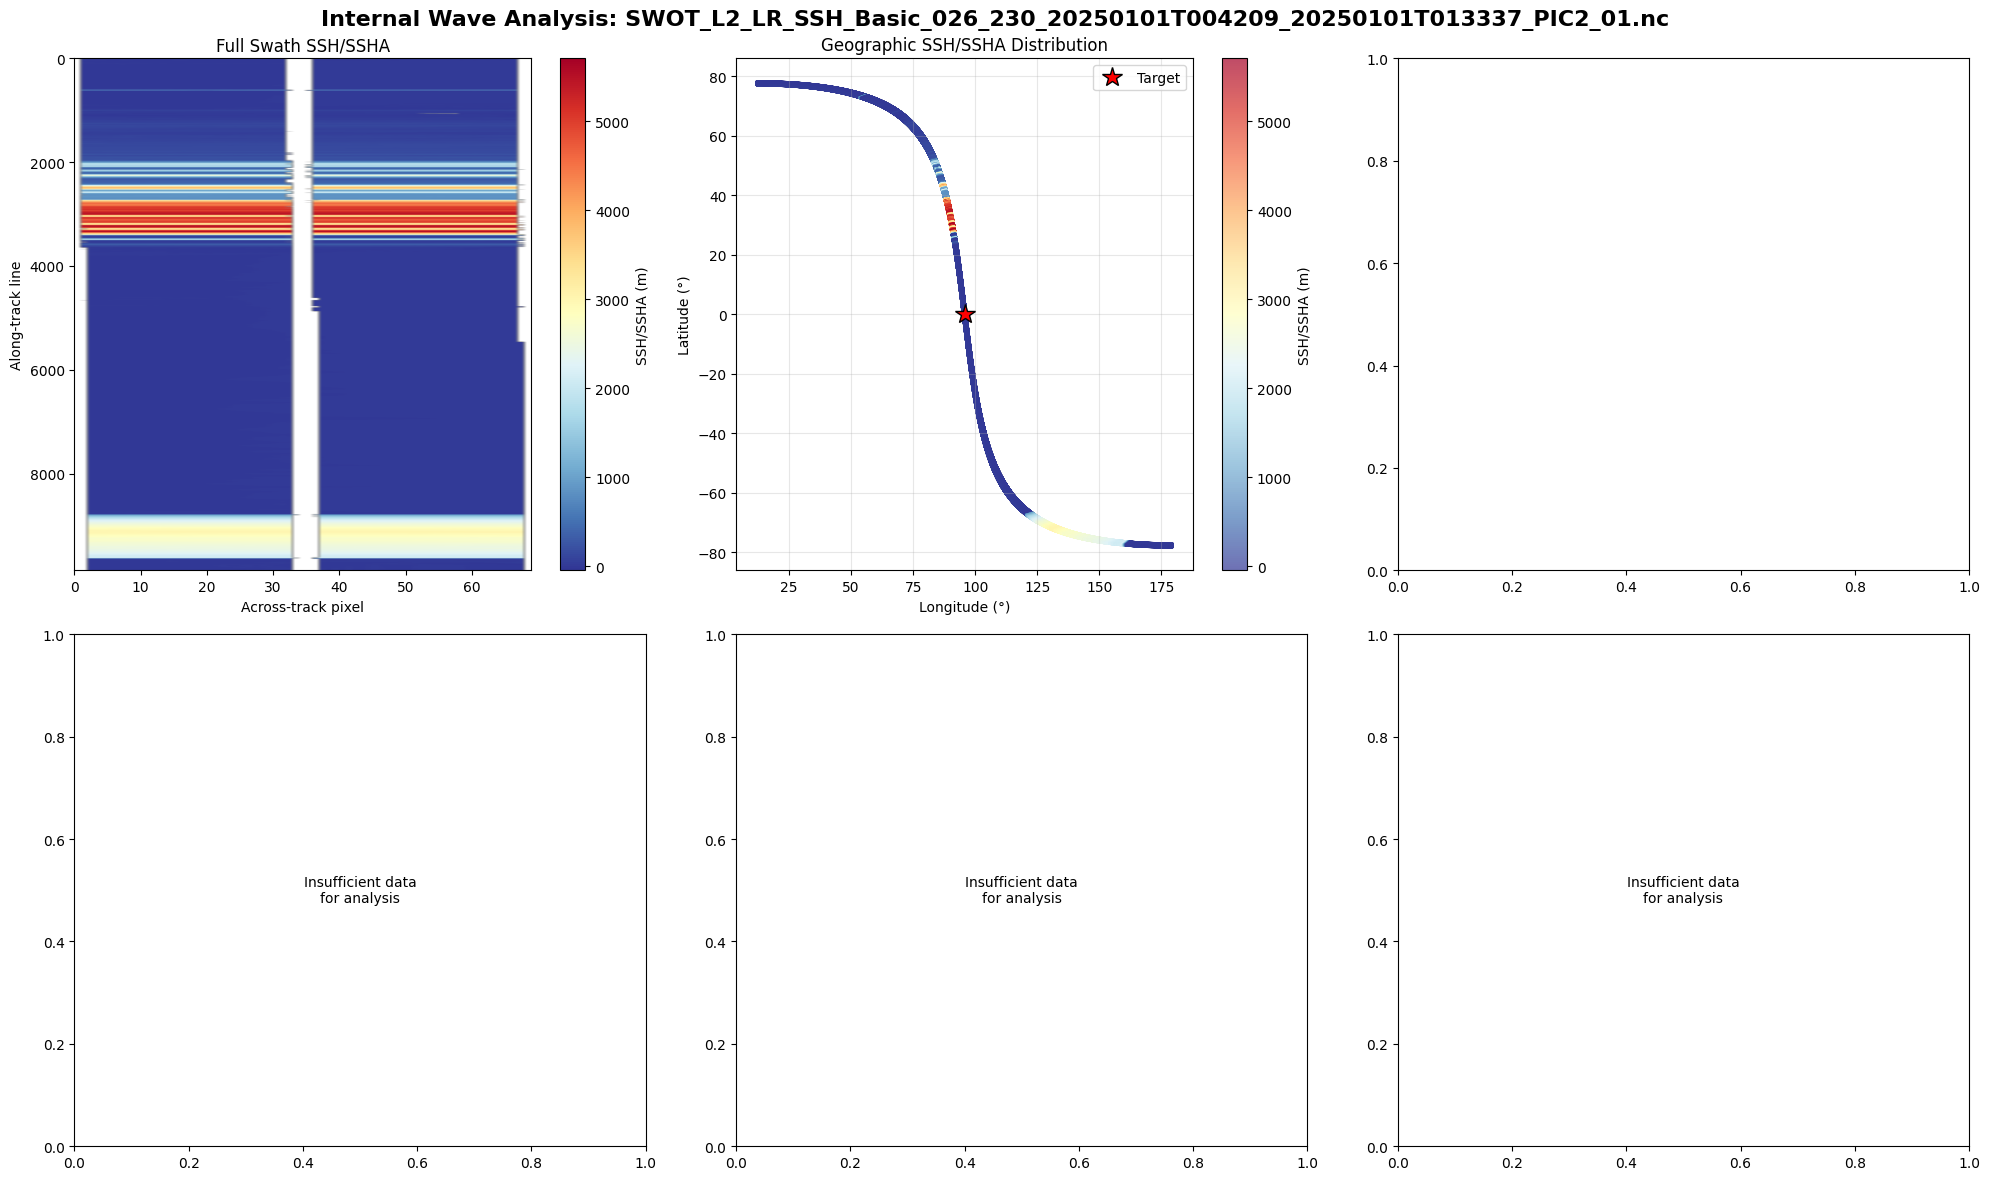

✓ Internal wave analysis completed for SWOT_L2_LR_SSH_Basic_026_230_20250101T004209_20250101T013337_PIC2_01.nc

Analyzing file 2/3: SWOT_L2_LR_SSH_Basic_026_258_20250102T004240_20250102T013408_PIC2_01.nc
Timestamp: 2025-01-02 00:42:40


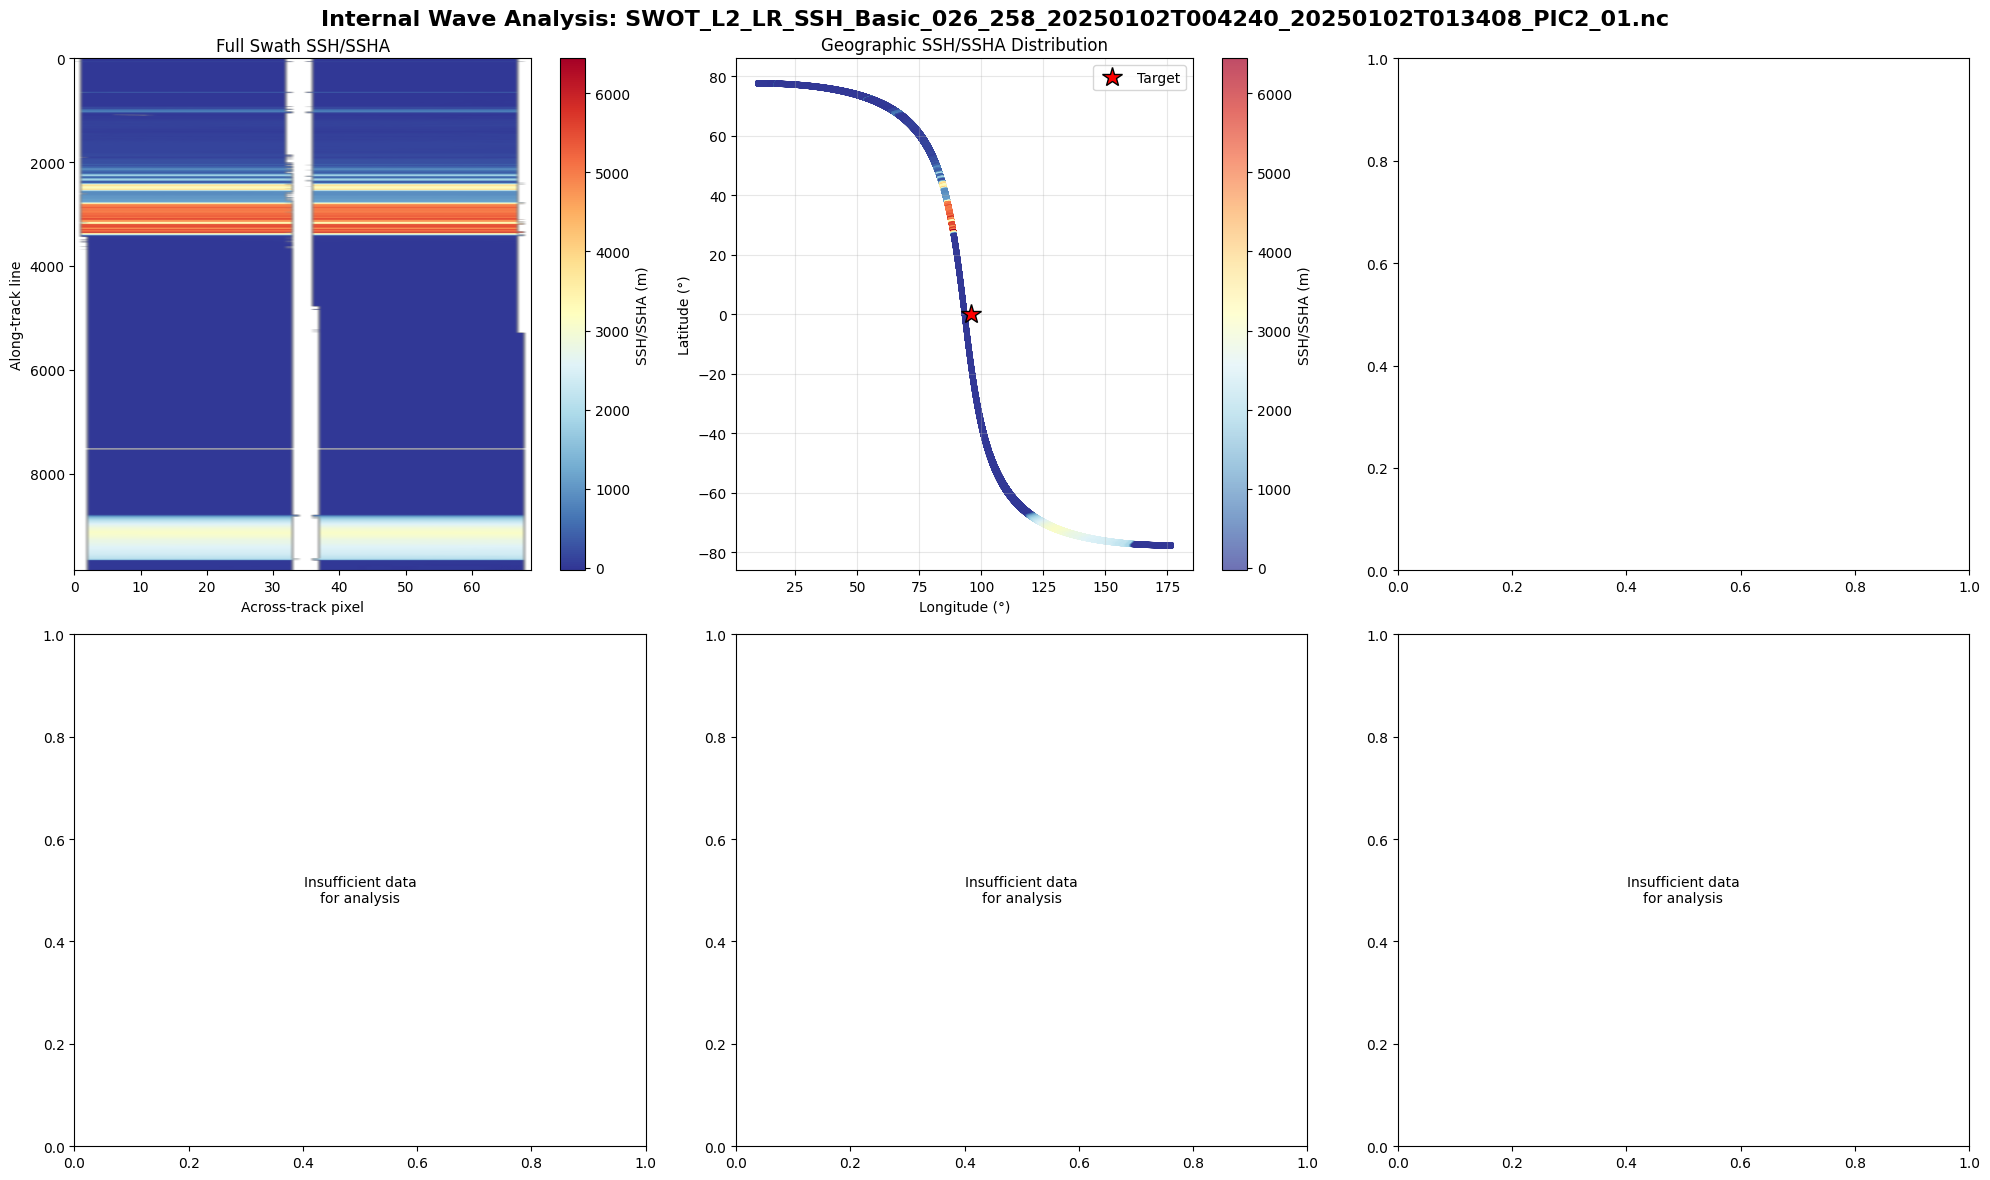

✓ Internal wave analysis completed for SWOT_L2_LR_SSH_Basic_026_258_20250102T004240_20250102T013408_PIC2_01.nc

Analyzing file 3/3: SWOT_L2_LR_SSH_Basic_026_424_20250107T230252_20250107T233924_PIC2_01.nc
Timestamp: 2025-01-07 23:02:52


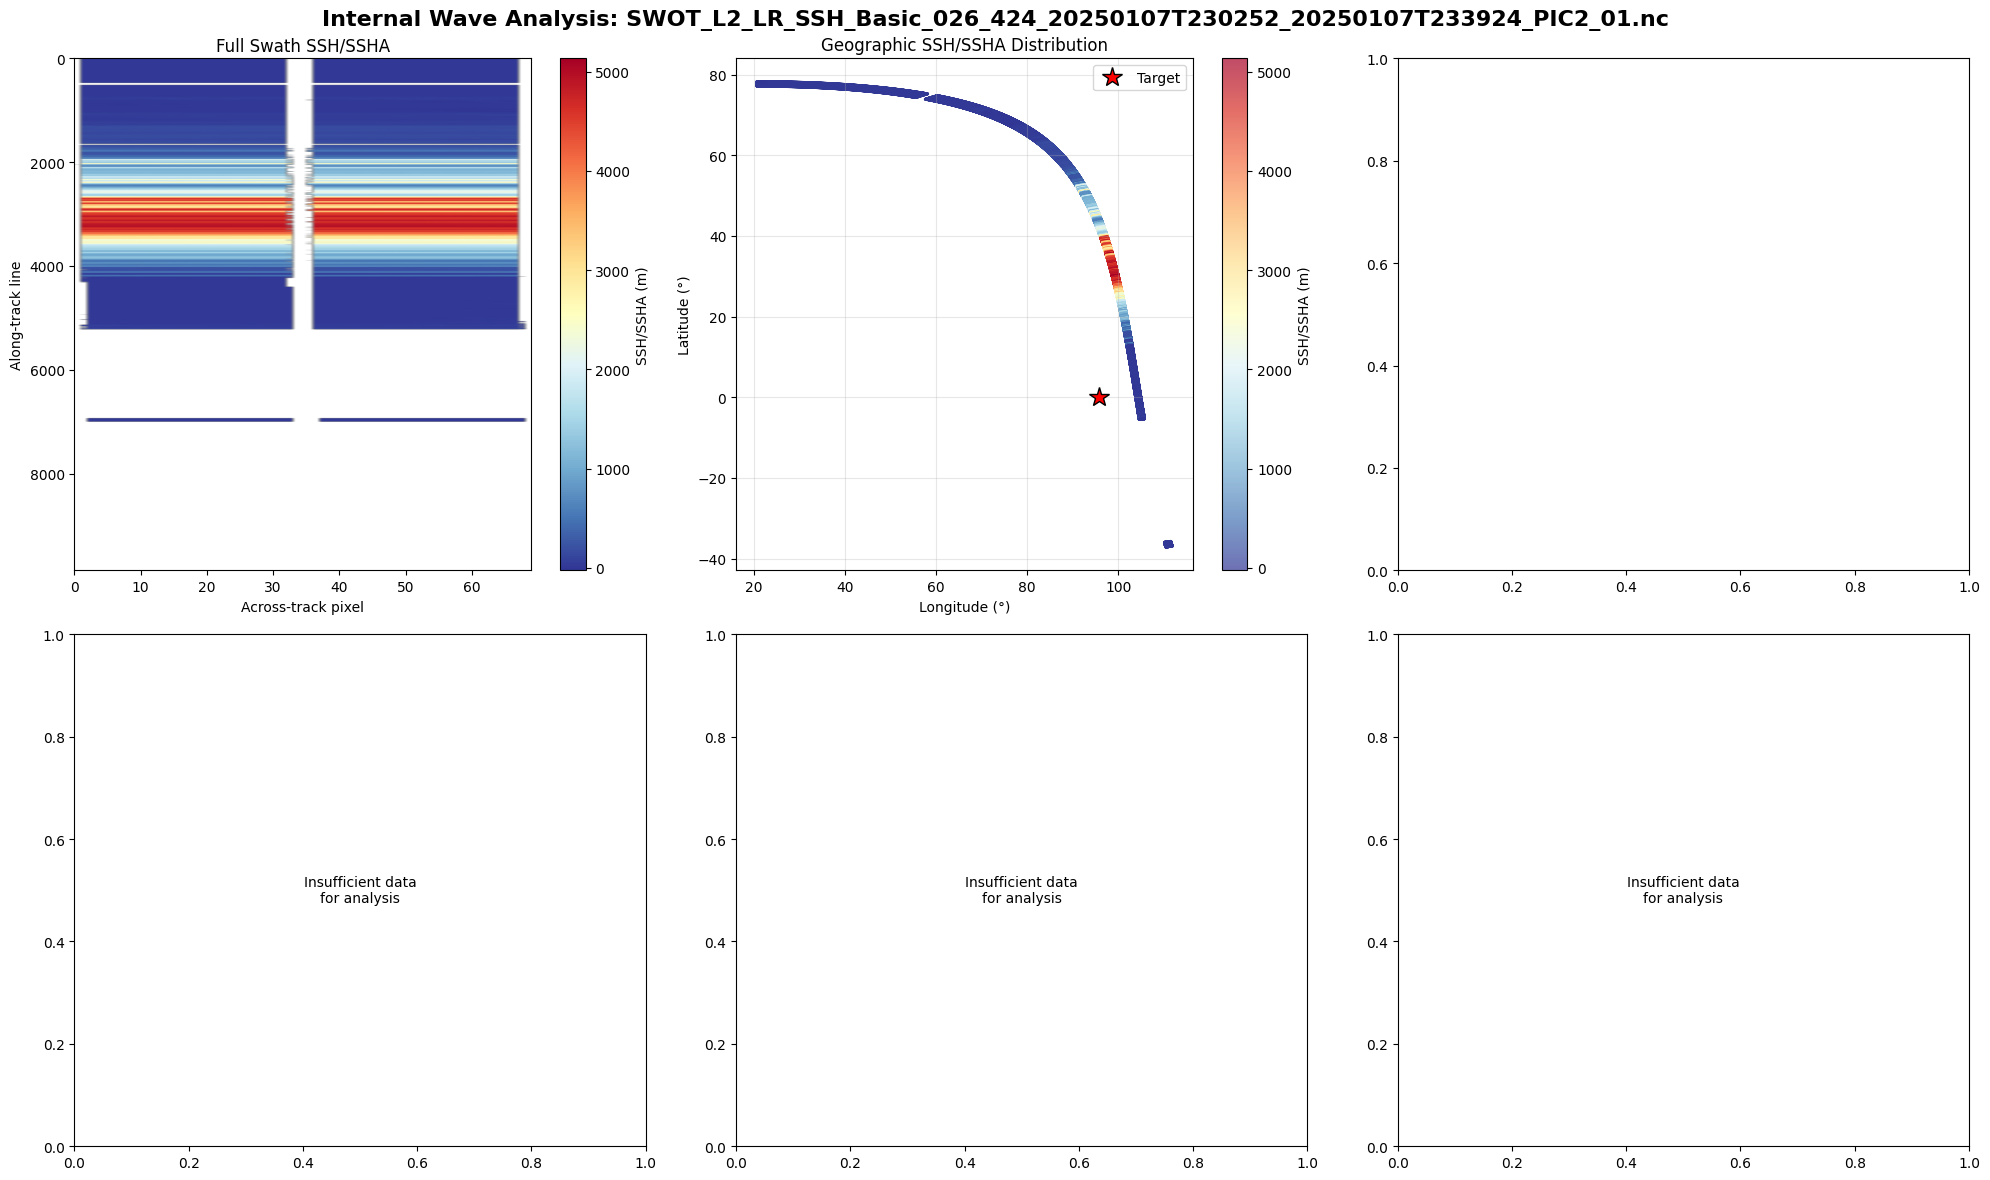

✓ Internal wave analysis completed for SWOT_L2_LR_SSH_Basic_026_424_20250107T230252_20250107T233924_PIC2_01.nc

✓ Internal wave analysis completed for 3 files

Internal wave analysis includes:
1. Full swath SSH/SSHA visualization
2. Geographic distribution of measurements
3. Along-track analysis at target location
4. High-pass filtered internal wave signals
5. Internal wave amplitude distributions
6. Power spectral density of internal waves
Export skipped - insufficient processed data available.


In [9]:
def analyze_internal_waves(file_path, target_lat, target_lon, window_count=25):
    """
    Advanced internal wave analysis with high-pass filtering and swath visualization
    """
    try:
        ds = xr.open_dataset(file_path, mask_and_scale=True)
        
        # Get coordinate and data variables
        lat = ds["latitude"] if "latitude" in ds.variables else ds["lat"]
        lon = ds["longitude"] if "longitude" in ds.variables else ds["lon"]
        
        if float(lon.max()) > 180.0:
            lon = to_180(lon)
        
        # Get SSH/SSHA data
        data_candidates, _ = get_ssha_varnames(prefer_ssha=USE_SSHA_FIRST)
        try:
            ssh_var = pick_var(ds, data_candidates)
        except KeyError:
            ssh_var = pick_var(ds, ["ssh_karin_2", "ssh_karin"])
        
        ssh_data = ssh_var.values
        lat_data = lat.values
        lon_data = lon.values
        
        # Create comprehensive swath visualization
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle(f'Internal Wave Analysis: {os.path.basename(file_path)}', fontsize=16, fontweight='bold')
        
        # 1. Full swath SSH
        im1 = axes[0, 0].imshow(ssh_data, cmap='RdYlBu_r', aspect='auto', 
                               extent=[0, ssh_data.shape[1], ssh_data.shape[0], 0])
        axes[0, 0].set_title('Full Swath SSH/SSHA')
        axes[0, 0].set_xlabel('Across-track pixel')
        axes[0, 0].set_ylabel('Along-track line')
        plt.colorbar(im1, ax=axes[0, 0], label='SSH/SSHA (m)')
        
        # 2. Geographic view
        valid_mask = ~np.isnan(ssh_data) & ~np.isnan(lat_data) & ~np.isnan(lon_data)
        if np.any(valid_mask):
            scatter = axes[0, 1].scatter(lon_data[valid_mask], lat_data[valid_mask], 
                                       c=ssh_data[valid_mask], cmap='RdYlBu_r', s=1, alpha=0.7)
            axes[0, 1].set_xlabel('Longitude (°)')
            axes[0, 1].set_ylabel('Latitude (°)')
            axes[0, 1].set_title('Geographic SSH/SSHA Distribution')
            axes[0, 1].grid(True, alpha=0.3)
            plt.colorbar(scatter, ax=axes[0, 1], label='SSH/SSHA (m)')
            
            # Mark target location
            axes[0, 1].plot(target_lon, target_lat, 'r*', markersize=15, 
                          markeredgecolor='black', markeredgewidth=1, label='Target')
            axes[0, 1].legend()
        
        # 3. Find pixel nearest to target and analyze along-track
        if len(ssh_data.shape) == 2 and ssh_data.shape[0] > window_count * 2:
            # Find nearest pixel to target
            if not np.all(np.isnan(lat_data[0, :])) and not np.all(np.isnan(lon_data[0, :])):
                distances = np.sqrt((lat_data[0, :] - target_lat)**2 + 
                                  (lon_data[0, :] - target_lon)**2)
                nearest_pixel = np.nanargmin(distances)
                
                # Extract along-track data at nearest pixel
                along_track = ssh_data[:, nearest_pixel]
                valid_indices = ~np.isnan(along_track)
                
                if np.sum(valid_indices) > window_count * 2:
                    track_data = along_track[valid_indices]
                    track_indices = np.where(valid_indices)[0]
                    
                    # Apply high-pass filter (rolling mean subtraction)
                    track_series = pd.Series(track_data, index=track_indices)
                    rolling_mean = track_series.rolling(window=window_count, center=True, 
                                                      min_periods=max(3, window_count//3)).mean()
                    high_pass = track_series - rolling_mean
                    
                    # Plot along-track analysis
                    axes[0, 2].plot(track_indices, track_data, 'b-', alpha=0.7, 
                                   linewidth=1, label='Original')
                    axes[0, 2].plot(track_indices, rolling_mean.values, 'r-', 
                                   linewidth=2, label=f'Rolling Mean (n={window_count})')
                    axes[0, 2].set_xlabel('Along-track index')
                    axes[0, 2].set_ylabel('SSH/SSHA (m)')
                    axes[0, 2].set_title(f'Along-track at Pixel {nearest_pixel}')
                    axes[0, 2].legend()
                    axes[0, 2].grid(True, alpha=0.3)
                    
                    # Plot high-pass filtered data (internal wave signal)
                    axes[1, 0].plot(track_indices, high_pass.values, 'purple', 
                                   linewidth=1.5, alpha=0.8)
                    axes[1, 0].set_xlabel('Along-track index')
                    axes[1, 0].set_ylabel('High-pass SSH/SSHA (m)')
                    axes[1, 0].set_title('Internal Wave Signal\n(High-pass filtered)')
                    axes[1, 0].grid(True, alpha=0.3)
                    
                    # Statistics of internal wave signal
                    hw_stats = high_pass.dropna()
                    if len(hw_stats) > 0:
                        axes[1, 1].hist(hw_stats.values, bins=30, alpha=0.7, 
                                       color='purple', edgecolor='black')
                        axes[1, 1].axvline(hw_stats.mean(), color='red', linestyle='--', 
                                         label=f'Mean: {hw_stats.mean():.4f}m')
                        axes[1, 1].axvline(hw_stats.std(), color='orange', linestyle='--', 
                                         label=f'Std: {hw_stats.std():.4f}m')
                        axes[1, 1].set_xlabel('High-pass SSH/SSHA (m)')
                        axes[1, 1].set_ylabel('Frequency')
                        axes[1, 1].set_title('Internal Wave Amplitude Distribution')
                        axes[1, 1].legend()
                        axes[1, 1].grid(True, alpha=0.3)
                        
                        # Power spectral density of internal wave signal
                        if len(hw_stats) > 20:
                            hw_clean = hw_stats.values - np.mean(hw_stats.values)
                            frequencies, psd = signal.periodogram(hw_clean, fs=1.0)
                            
                            axes[1, 2].loglog(frequencies[1:], psd[1:], 'purple', alpha=0.8)
                            axes[1, 2].set_xlabel('Frequency (cycles/point)')
                            axes[1, 2].set_ylabel('Power Spectral Density')
                            axes[1, 2].set_title('Internal Wave PSD')
                            axes[1, 2].grid(True, alpha=0.3)
                            
                            # Calculate key statistics
                            rms_amplitude = np.sqrt(np.mean(hw_clean**2))
                            peak_freq = frequencies[1:][np.argmax(psd[1:])]
                            
                            stats_text = f'RMS Amplitude: {rms_amplitude:.4f}m\n'
                            stats_text += f'Peak Frequency: {peak_freq:.3f} cyc/pt\n'
                            stats_text += f'Data points: {len(hw_clean)}'
                            
                            axes[1, 2].text(0.05, 0.95, stats_text, transform=axes[1, 2].transAxes,
                                           verticalalignment='top', bbox=dict(boxstyle='round', 
                                           facecolor='wheat', alpha=0.8))
                        else:
                            axes[1, 2].text(0.5, 0.5, 'Insufficient data\nfor PSD analysis', 
                                           ha='center', va='center', transform=axes[1, 2].transAxes)
                    else:
                        axes[1, 1].text(0.5, 0.5, 'No valid\nhigh-pass data', 
                                       ha='center', va='center', transform=axes[1, 1].transAxes)
                        axes[1, 2].text(0.5, 0.5, 'No valid\nhigh-pass data', 
                                       ha='center', va='center', transform=axes[1, 2].transAxes)
                else:
                    for ax in [axes[1, 0], axes[1, 1], axes[1, 2]]:
                        ax.text(0.5, 0.5, 'Insufficient data\nfor analysis', 
                               ha='center', va='center', transform=ax.transAxes)
            else:
                for ax in axes[0, 2:].flatten():
                    ax.text(0.5, 0.5, 'Invalid coordinate\ndata', 
                           ha='center', va='center', transform=ax.transAxes)
                for ax in axes[1, :].flatten():
                    ax.text(0.5, 0.5, 'Invalid coordinate\ndata', 
                           ha='center', va='center', transform=ax.transAxes)
        else:
            for ax in [axes[0, 2]] + axes[1, :].tolist():
                ax.text(0.5, 0.5, 'Insufficient data\nfor along-track analysis', 
                       ha='center', va='center', transform=ax.transAxes)
        
        plt.tight_layout()
        plt.show()
        
        ds.close()
        return fig
        
    except Exception as e:
        print(f"Error in internal wave analysis for {os.path.basename(file_path)}: {e}")
        return None

# Perform internal wave analysis on representative files
if 'sorted_files' in locals() and len(sorted_files) > 0 and TARGET_LAT is not None and TARGET_LON is not None:
    print("Performing Internal Wave Analysis")
    print("=" * 50)
    
    # Analyze first few files as examples
    analysis_files = sorted_files[:3]  # First 3 files
    
    for i, (timestamp, file_path, filename) in enumerate(analysis_files):
        print(f"\nAnalyzing file {i+1}/{len(analysis_files)}: {filename}")
        print(f"Timestamp: {timestamp}")
        
        fig = analyze_internal_waves(file_path, TARGET_LAT, TARGET_LON, ROLLING_MEAN_COUNT)
        
        if fig is not None:
            print(f"✓ Internal wave analysis completed for {filename}")
        else:
            print(f"❌ Internal wave analysis failed for {filename}")
    
    print(f"\n✓ Internal wave analysis completed for {len(analysis_files)} files")
    print("\nInternal wave analysis includes:")
    print("1. Full swath SSH/SSHA visualization")
    print("2. Geographic distribution of measurements")
    print("3. Along-track analysis at target location")
    print("4. High-pass filtered internal wave signals")
    print("5. Internal wave amplitude distributions")
    print("6. Power spectral density of internal waves")
    
else:
    print("Internal wave analysis requires valid target coordinates and data files.")

# Export enhanced results
if 'combined_df' in locals() and 'stats_df' in locals():
    print(f"\nExporting Enhanced Results...")
    print("=" * 40)
    
    # Create output directory
    output_dir = os.path.dirname(data_directory)
    timestamp_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Export detailed measurements
    detailed_csv = os.path.join(output_dir, f'swot_detailed_measurements_{timestamp_str}.csv')
    combined_df.to_csv(detailed_csv, index=False)
    print(f"✓ Detailed measurements saved: {detailed_csv}")
    
    # Export daily statistics
    daily_csv = os.path.join(output_dir, f'swot_daily_statistics_{timestamp_str}.csv')
    daily_stats.to_csv(daily_csv)
    print(f"✓ Daily statistics saved: {daily_csv}")
    
    # Export monthly statistics
    monthly_csv = os.path.join(output_dir, f'swot_monthly_statistics_{timestamp_str}.csv')
    monthly_stats.to_csv(monthly_csv)
    print(f"✓ Monthly statistics saved: {monthly_csv}")
    
    # Export file-based statistics
    file_csv = os.path.join(output_dir, f'swot_file_statistics_{timestamp_str}.csv')
    stats_df.to_csv(file_csv)
    print(f"✓ File statistics saved: {file_csv}")
    
    print(f"\n🎉 ENHANCED SWOT ANALYSIS COMPLETE! 🎉")
    print("=" * 60)
    print("Your analysis includes:")
    print("✓ Chronological file processing")
    print("✓ Quality-controlled data extraction")
    print("✓ Advanced statistical analysis")
    print("✓ Comprehensive visualizations")
    print("✓ Internal wave analysis")
    print("✓ High-pass filtering for wave detection")
    print("✓ Power spectral density analysis")
    print("✓ Geographic and temporal distribution analysis")
    print("✓ Exported datasets for further research")
    
else:
    print("Export skipped - insufficient processed data available.")